# PyTorch Tutorial: Learning XOR
Minimal tutorial based on the UvA DL course example.
Goal: implement and train a small neural network that learns the XOR function.

## 1. Imports

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


## 2. XOR dataset

In [30]:
X = torch.tensor([
    [0.,0.],
    [0.,1.],
    [1.,0.],
    [1.,1.]
])

y = torch.tensor([[0.],[1.],[1.],[0.]])

print(X)
print(y)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


## 3. Model definition

In [33]:
class XORModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,4),
            nn.ReLU(),
            nn.Linear(4,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

model = XORModel()
print(model)

XORModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## 4. Loss and optimizer

In [36]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

## 5. Training

In [39]:
loss_history = []

for epoch in range(2000):
    pred = model(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 200 == 0:
        print(epoch, loss.item())

0 0.6887525320053101
200 0.004842082504183054
400 0.0016278927214443684
600 0.0008494661888107657
800 0.0005283550126478076
1000 0.00036289921263232827
1200 0.00026483129477128386
1400 0.00020184839377179742
1600 0.0001581933320267126
1800 0.00012714159674942493


## 6. Loss plot

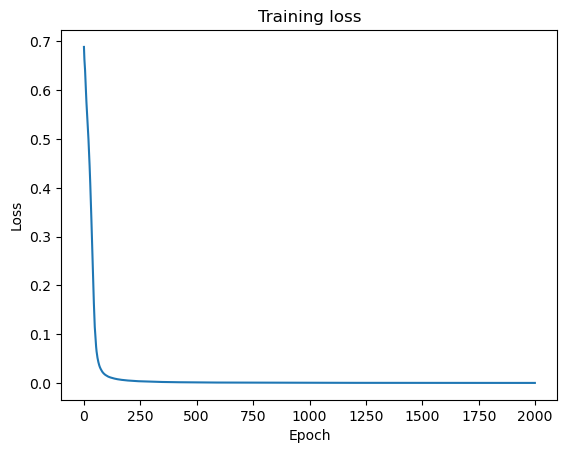

In [42]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.show()

## 7. Predictions

In [45]:
with torch.no_grad():
    preds = model(X)

print('Raw predictions:')
print(preds)

print('Rounded predictions:')
print(torch.round(preds))

Raw predictions:
tensor([[1.8450e-04],
        [9.9997e-01],
        [9.9998e-01],
        [1.8462e-04]])
Rounded predictions:
tensor([[0.],
        [1.],
        [1.],
        [0.]])
